## Expérimentation de modèles

In [8]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    cross_validate,
    GridSearchCV,
    learning_curve,
    HalvingGridSearchCV
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [9]:
train_data = pd.read_csv("../data/processed_dataset.csv")
test_data = pd.read_parquet("../data/test_data.parquet")

X_train = train_data.drop(["ID_Employe", "Satisfait"], axis=1).select_dtypes(include=["number"])
y_train = train_data["Satisfait"]

print(X_train)

          Age  Sexe  Annees_Experience  Niveau_Etudes  Salaire_Mensuel_BIF  \
0   -1.504765   1.0          -1.253933            1.0            -1.139103   
1    0.032863   1.0           0.276802            1.0             0.012165   
2    0.887101   0.0          -1.136184            0.0            -1.238136   
3   -0.906798   0.0           0.159053            1.0             0.451623   
4    0.887101   0.0           0.159053            1.0             0.288072   
..        ...   ...                ...            ...                  ...   
377 -1.248494   0.0          -1.018435            2.0             0.012165   
378  1.314220   0.0           2.278533            2.0             1.988563   
379  1.314220   1.0           0.159053            2.0             0.713706   
380  1.485068   1.0           2.867277            1.0             1.988563   
381  0.374558   0.0          -0.311942            1.0            -0.575604   

     Travail_A_Distance  Heures_Supplementaires  Heures_Formati

### Transformation de données de test

In [10]:

# Séparation de X_test et y_test
X_test = test_data.drop(["ID_Employe", "Satisfait"], axis=1).select_dtypes(include=["number"])
y_test = test_data["Satisfait"]

X_test

,Age,Sexe,Annees_Experience,Niveau_Etudes,Salaire_Mensuel_BIF,Travail_A_Distance,Heures_Supplementaires,Heures_Formation,Anciennete_Entreprise,Nombre_Promotions,...,Departement_Administration,Departement_Commercial,Departement_Finance,Departement_Informatique,Departement_Logistique,Departement_Marketing,Departement_Production,Departement_Recherche et Développement,Departement_Ressources Humaines,Departement_Support Client
0,0.203711,0.0,-0.311942,1.0,-0.187169,0.0,-1.289932,0.655394,-0.599124,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-1.590189,0.0,-0.900686,1.0,-0.920043,0.0,-0.672980,0.860110,-0.423750,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.479679,0.0,-0.782937,0.0,-0.840417,0.0,-0.056028,1.211052,-0.774498,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.024057,0.0,2.160784,1.0,0.652730,0.0,-1.289932,-0.221961,-0.949873,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-1.419341,0.0,-0.900686,1.0,-0.784460,0.0,0.120245,-1.070071,-0.599124,1.2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,0.801677,1.0,2.514031,1.0,1.419495,0.0,0.913469,-0.104980,3.609862,6.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
124,0.545406,0.0,-0.547440,0.0,-0.917386,0.0,-1.642476,-0.280451,0.102374,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
125,1.485068,1.0,1.572040,1.0,1.988563,0.0,-1.113660,0.421432,2.031492,1.2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
126,-0.906798,0.0,-0.311942,1.0,0.012349,0.0,0.913469,-1.596484,0.277748,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
def formated_time(second):
    m, s = divmod(second, 60)

    if m > 0:
         f"{int(m)} min {s:.4f} secondes"
    else:
        return f"{s:.4f} secondes"

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

In [12]:

def _learning_curve(model, model_name, X=X_train, y=y_train):
   
    metrics = {
        "Accuracy": {
            "scoring": "accuracy",
            "transform": lambda x: x,
            "ylabel": "Accuracy",
        },
        "F1-Score": {
            "scoring": "f1",
            "transform": lambda x: x,
            "ylabel": "F1-Score",
        },
        "ROC-AUC": {
            "scoring": "roc_auc",
            "transform": lambda x: x,
            "ylabel": "ROC-AUC",
        },
    }

    fig, axes = plt.subplots(3, 3, figsize=(17, 12))
    axes_flat = axes.flatten()

    for i, (metric_name, metric_info) in enumerate(metrics.items()):
        ax = axes_flat[i]

        try:
            train_sizes, train_scores, test_scores = learning_curve(
                estimator=model,
                X=X,
                y=y,
                train_sizes=np.linspace(0.1, 1.0, 10),
                cv=10,
                scoring=metric_info["scoring"],
                n_jobs=-1,
                random_state=40,
                shuffle=True
            )

            train_scores_trans = metric_info["transform"](train_scores)
            test_scores_trans = metric_info["transform"](test_scores)

            train_mean = train_scores_trans.mean(axis=1)
            train_std = train_scores_trans.std(axis=1)
            test_mean = test_scores_trans.mean(axis=1)
            test_std = test_scores_trans.std(axis=1)

            ax.plot(train_sizes, train_mean, "o-", color="red", label="Score entraînement")
            ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="red")
            ax.plot(train_sizes, test_mean, "o-", color="blue", label="Score validation")
            ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="blue")

            ax.set_title(f"{metric_name}")
            ax.set_xlabel("Exemples d'entraînement")
            ax.set_ylabel(metric_info["ylabel"])
            ax.legend(loc="best")
            ax.grid(True)
            
        except Exception as e:
            ax.text(0.5, 0.5, f"Erreur: {str(e)}", ha='center', va='center', color='red')
            ax.set_title(f"{metric_name} (Échec)")

    model.fit(X, y)
    
    y_pred = model.predict(X)
    
    try:
        y_proba = model.predict_proba(X)[:, 1]
        has_proba = True
    except AttributeError:
        has_proba = False

    ax_conf = axes_flat[3]
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=ax_conf, cmap="Blues", colorbar=False)
    ax_conf.set_title("Matrice de Confusion")
    ax_conf.set_xlabel("") 
    ax_conf.set_ylabel("")

    ax_proba = axes_flat[4]
    
    if has_proba:
        proba_true = y_proba[y == 1]
        proba_false = y_proba[y == 0]

        ax_proba.hist(proba_false, bins=30, alpha=0.5, label="Classe Réelle 0", color="red", density=True)
        ax_proba.hist(proba_true, bins=30, alpha=0.5, label="Classe Réelle 1", color="blue", density=True)
        
        ax_proba.axvline(x=0.5, color="black", linestyle="--", lw=2, label="Seuil de décision (0.5)")
        ax_proba.set_title("Distribution des Probabilités Prédites")
        ax_proba.set_xlabel("Probabilité Classe Positive")
        ax_proba.set_ylabel("Densité")
        ax_proba.legend(loc="best")
        ax_proba.grid(True, alpha=0.3)
    else:
        ax_proba.text(0.5, 0.5, "Modèle ne supporte pas\npredict_proba", ha='center', va='center', color='orange')
        ax_proba.set_title("Probabilités non disponibles")

    for j in range(5, 9):
        fig.delaxes(axes_flat[j])

    fig.suptitle(f"Évaluation du Modèle de Classification - {model_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()   

### Modèle de Régression Linéaire

/home/luckson/.virtualenvs/jupyter_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/luckson/.virtualenvs/jupyter_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/luck

Fit Time : [0.09381604 0.01609182 0.01584339 0.01640201 0.01984978]

Score Time : [0.03011155 0.02903056 0.02893281 0.02832341 0.03098845]

Test Accuracy : [0.88311688 0.84415584 0.94736842 0.89473684 0.88157895]

Test Precision : [0.87755102 0.82692308 0.91836735 0.87755102 0.92857143]

Test recall : [0.93478261 0.93478261 1.         0.95555556 0.86666667]

Test F1 : [0.90526316 0.87755102 0.95744681 0.91489362 0.89655172]


/home/luckson/.virtualenvs/jupyter_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/luckson/.virtualenvs/jupyter_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/luck

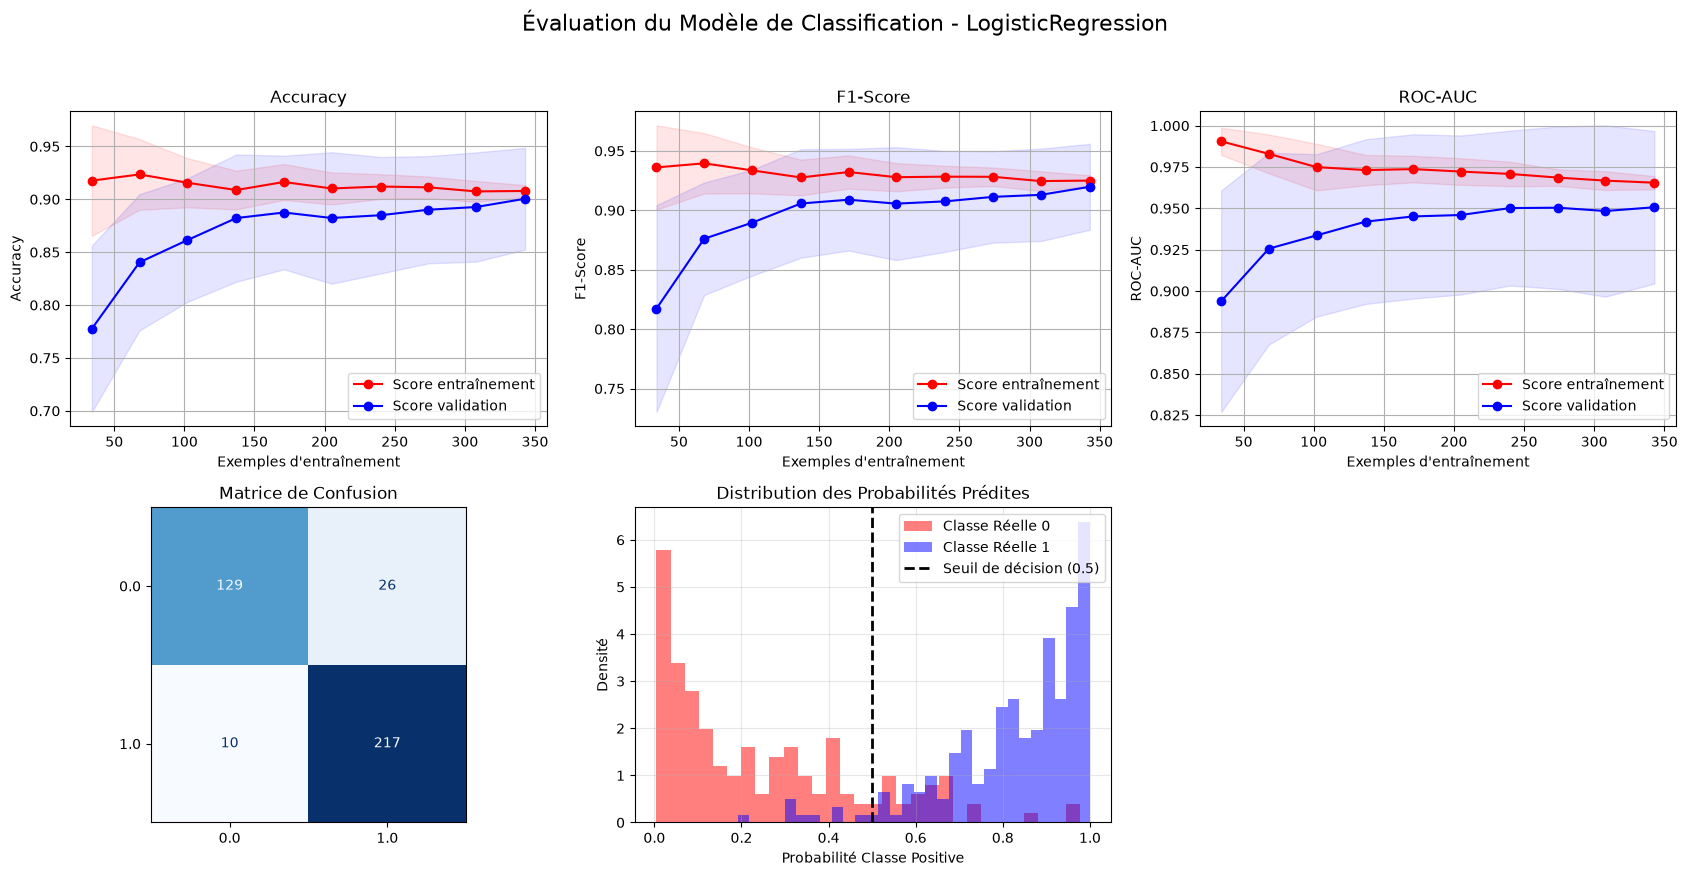

In [13]:
# Lasso model
# logistic_model = LogisticRegression(
#     penalty="l1",
#     solver="saga",
#     C=0.1,
#     max_iter=1000,
# )

# Ridge model
logistic_model = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    C=0.1,
    max_iter=1000,
)

logistic_scores = cross_validate(logistic_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {logistic_scores["fit_time"]}")
print()
print(f"Score Time : {logistic_scores["score_time"]}")
print()
print(f"Test Accuracy : {logistic_scores["test_accuracy"]}")
print()
print(f"Test Precision : {logistic_scores["test_precision"]}")
print()
print(f"Test recall : {logistic_scores["test_recall"]}")
print()
print(f"Test F1 : {logistic_scores["test_f1"]}")

_learning_curve(
    model=logistic_model,
    model_name="LogisticRegression",
)

### Arbres de décision

Fit Time : [0.00892019 0.00642014 0.01180911 0.01159739 0.00745416]

Score Time : [0.02656698 0.05395007 0.08083725 0.03888154 0.03294945]

Test Accuracy : [0.74025974 0.67532468 0.75       0.71052632 0.71052632]

Test Precision : [0.80952381 0.74418605 0.825      0.7804878  0.81081081]

Test recall : [0.73913043 0.69565217 0.73333333 0.71111111 0.66666667]

Test F1 : [0.77272727 0.71910112 0.77647059 0.74418605 0.73170732]


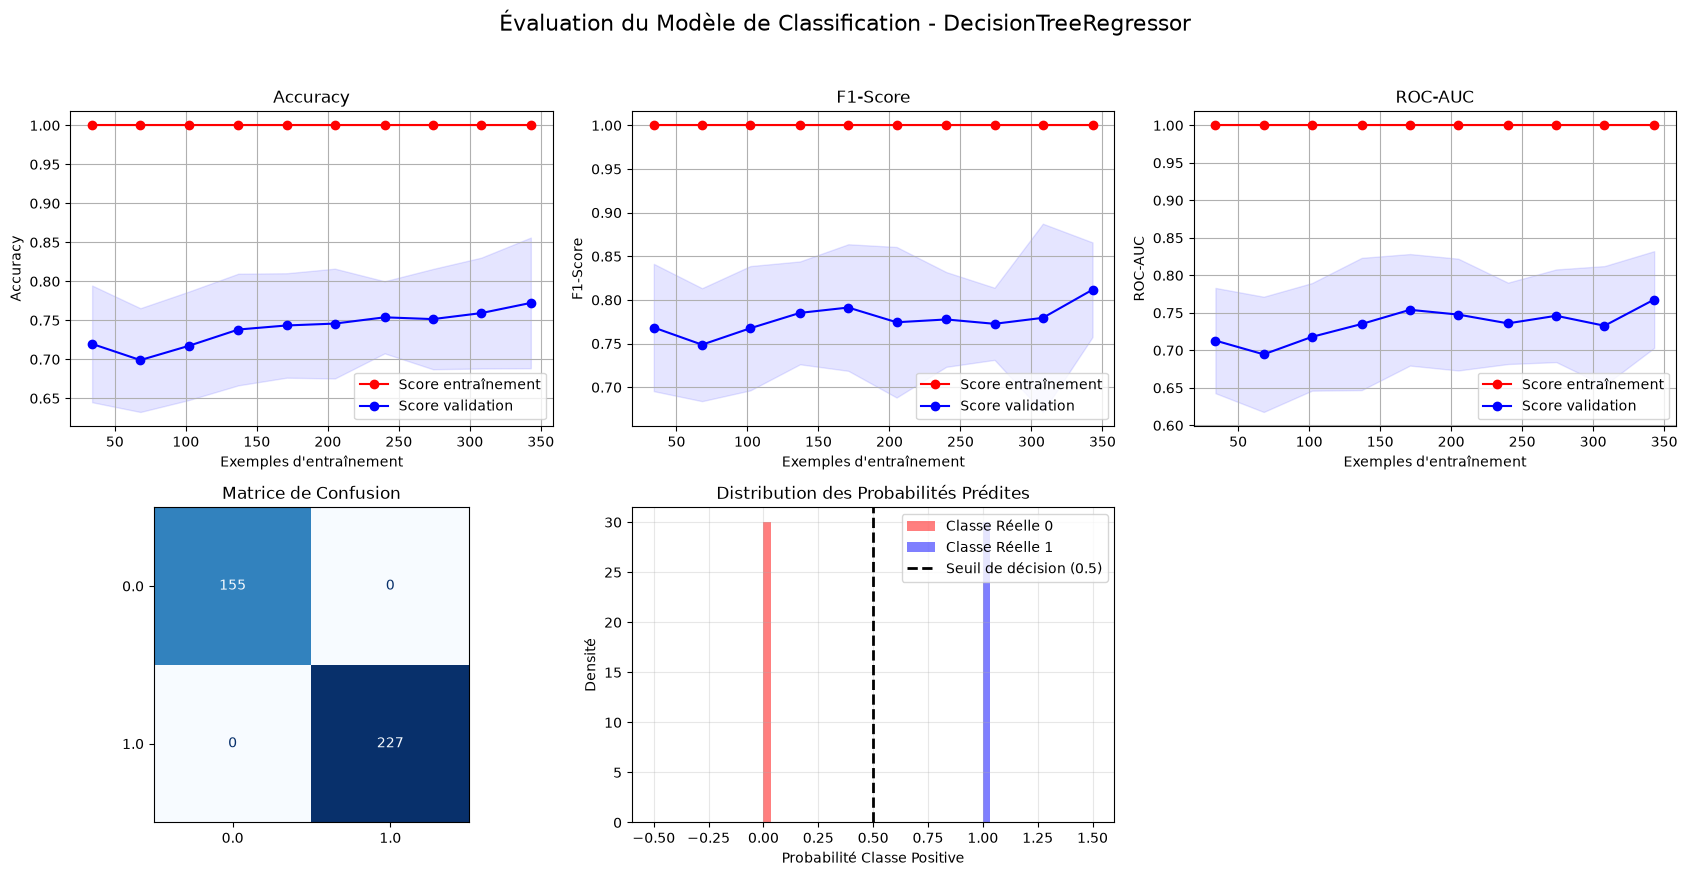

In [14]:
tree_model = DecisionTreeClassifier()
tree_scores = cross_validate(tree_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {tree_scores["fit_time"]}")
print()
print(f"Score Time : {tree_scores["score_time"]}")
print()
print(f"Test Accuracy : {tree_scores["test_accuracy"]}")
print()
print(f"Test Precision : {tree_scores["test_precision"]}")
print()
print(f"Test recall : {tree_scores["test_recall"]}")
print()
print(f"Test F1 : {tree_scores["test_f1"]}")

_learning_curve(
    model=tree_model,
    model_name="DecisionTreeRegressor",
)

### Modèle de Fôrets Aléatoire

Fit Time : [0.25933528 0.20022511 0.22093701 0.28147721 0.19235301]

Score Time : [0.05392599 0.0441072  0.0519774  0.04506779 0.04256511]

Test Accuracy : [0.80519481 0.81818182 0.89473684 0.82894737 0.85526316]

Test Precision : [0.80392157 0.80769231 0.8490566  0.83333333 0.925     ]

Test recall : [0.89130435 0.91304348 1.         0.88888889 0.82222222]

Test F1 : [0.84536082 0.85714286 0.91836735 0.86021505 0.87058824]


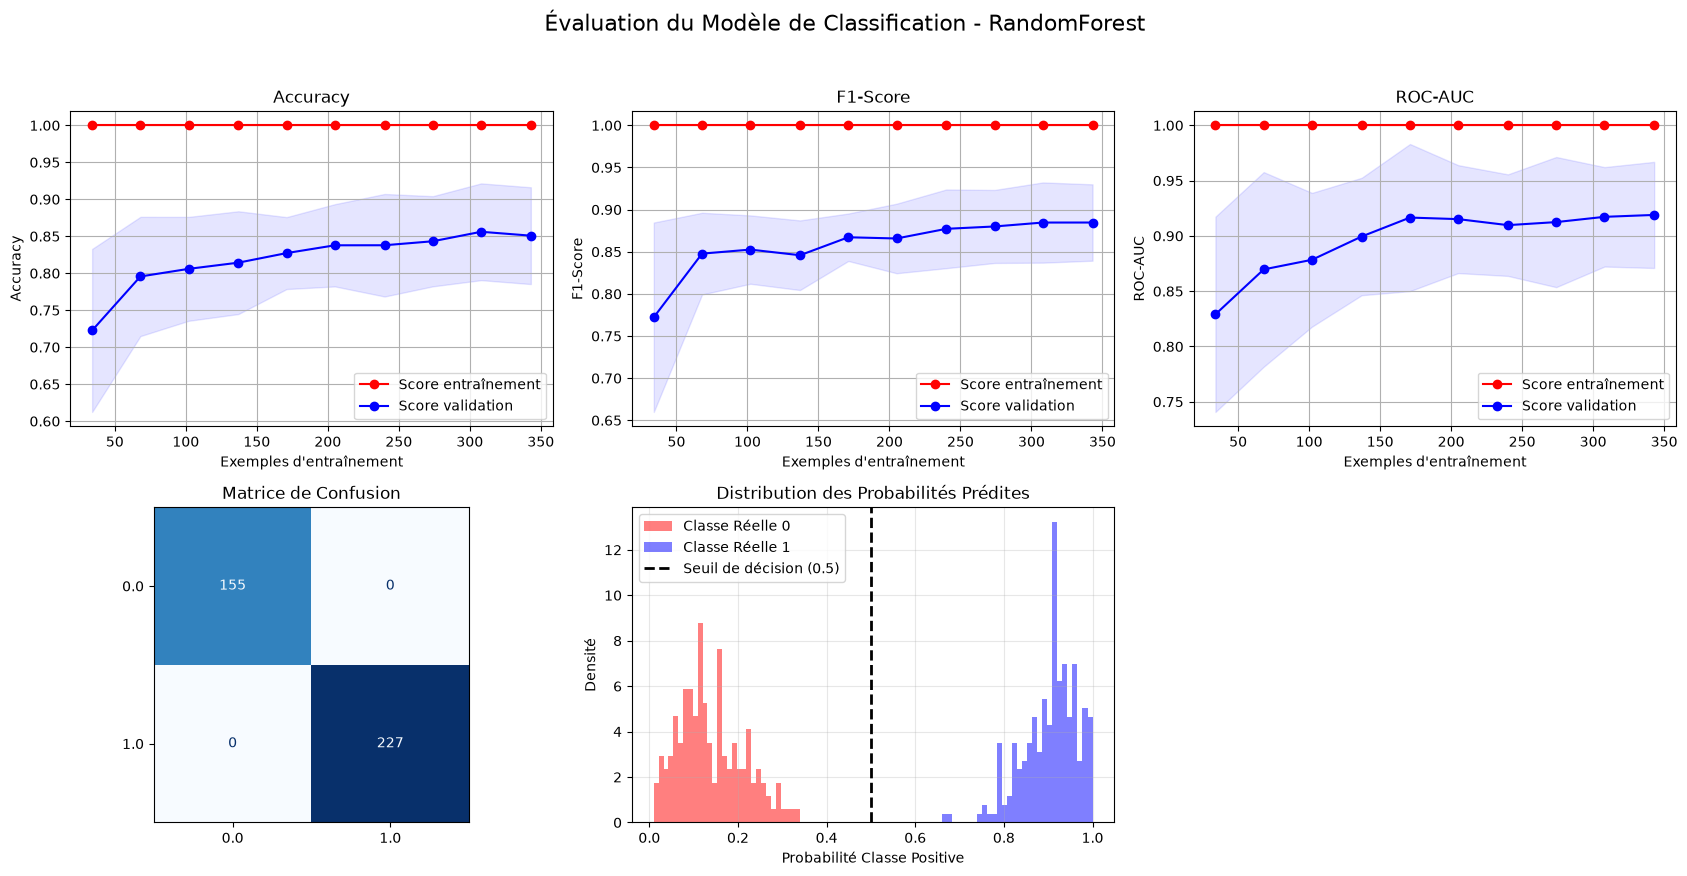

In [15]:
random_model = RandomForestClassifier()

random_scores = cross_validate(random_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {random_scores["fit_time"]}")
print()
print(f"Score Time : {random_scores["score_time"]}")
print()
print(f"Test Accuracy : {random_scores["test_accuracy"]}")
print()
print(f"Test Precision : {random_scores["test_precision"]}")
print()
print(f"Test recall : {random_scores["test_recall"]}")
print()
print(f"Test F1 : {random_scores["test_f1"]}")

_learning_curve(
    model=random_model,
    model_name="RandomForest",
)

### Modèle de Gradient Boosting

Fit Time : [0.70006084 0.56531811 0.52738786 0.52085948 0.55918431]

Score Time : [0.0229435  0.0220077  0.02176857 0.02129936 0.02313352]

Test Accuracy : [0.80519481 0.76623377 0.88157895 0.82894737 0.86842105]

Test Precision : [0.84444444 0.80434783 0.875      0.83333333 0.92682927]

Test recall : [0.82608696 0.80434783 0.93333333 0.88888889 0.84444444]

Test F1 : [0.83516484 0.80434783 0.90322581 0.86021505 0.88372093]


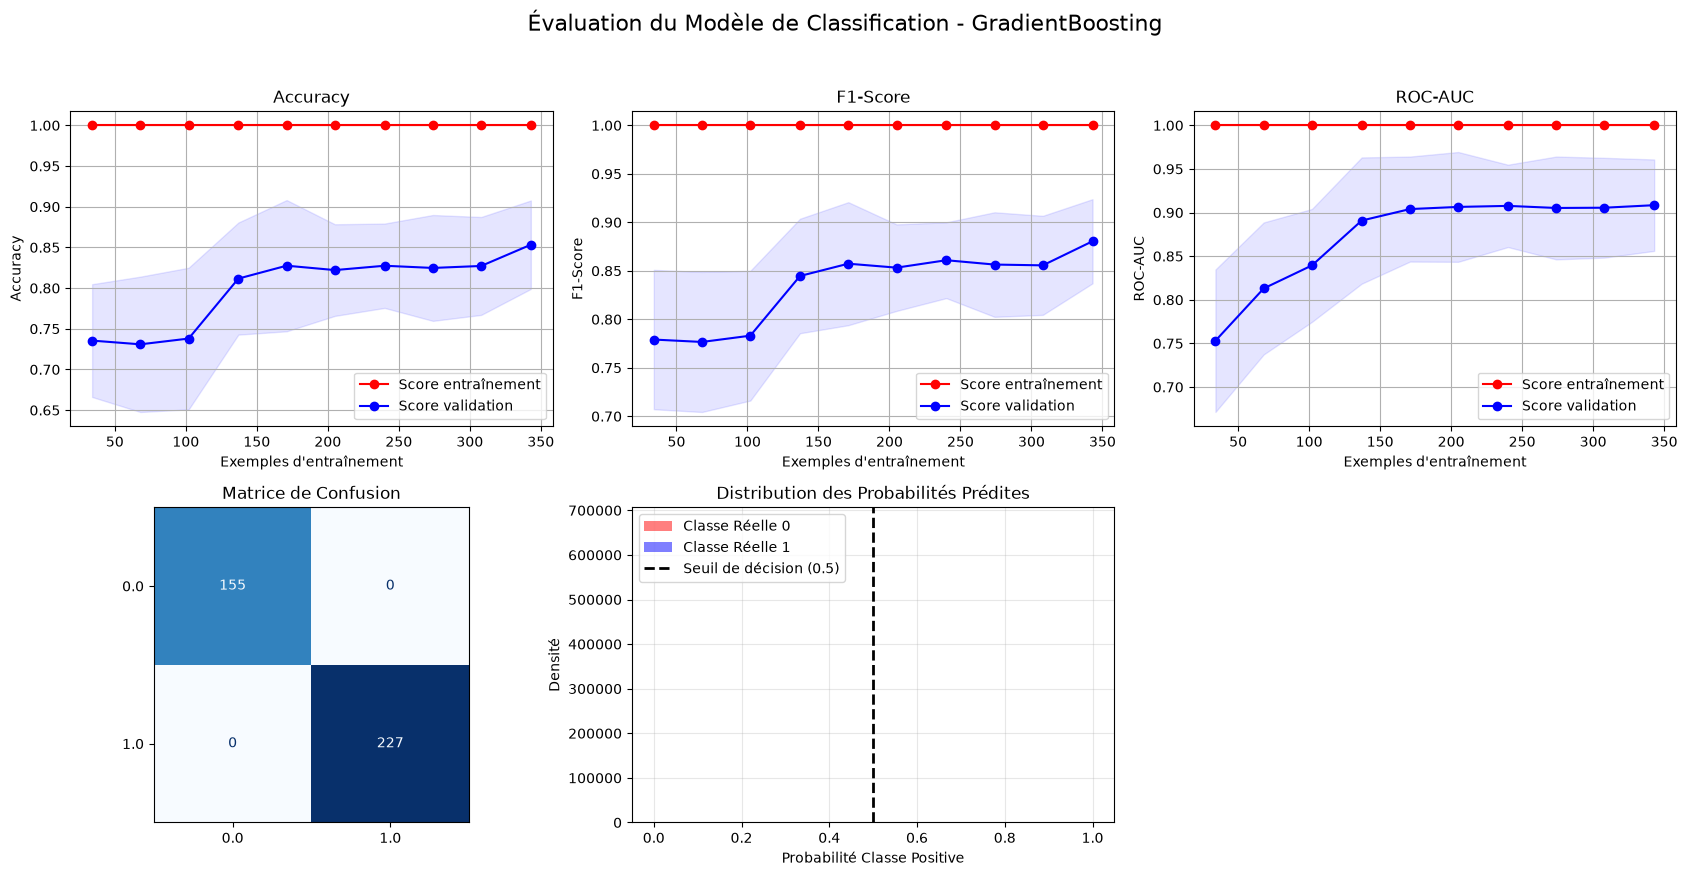

In [16]:
# param_grid = {
#     "n_estimators": np.linspace(50, 500, 5, dtype=int).tolist(),
#     "learning_rate": np.logspace(-5, -1, 5).tolist(),
#     "max_depth": np.linspace(1, 20, 4, dtype=int).tolist(),
#     "subsample": np.linspace(0.5, 1.0, 4).tolist()
# }

boosting_model = GradientBoostingClassifier(
    learning_rate=0.2,
    n_estimators=162,
    max_depth=5,
    random_state=42
)

boosting_scores = cross_validate(boosting_model, X_train, y_train, scoring=scoring)

# search = HalvingGridSearchCV(
#     estimator=boosting_model,
#     param_grid=param_grid,
#     factor=2,
#     aggressive_elimination=True,
#     cv=5,
#     scoring="neg_mean_squared_error",
#     n_jobs=-1,
#     random_state=42
# )

# search.fit(X_train, y_train)

# print(search.best_score_)
# print(search.best_params_)
# print(search.best_estimator_)

print(f"Fit Time : {boosting_scores["fit_time"]}")
print()
print(f"Score Time : {boosting_scores["score_time"]}")
print()
print(f"Test Accuracy : {boosting_scores["test_accuracy"]}")
print()
print(f"Test Precision : {boosting_scores["test_precision"]}")
print()
print(f"Test recall : {boosting_scores["test_recall"]}")
print()
print(f"Test F1 : {boosting_scores["test_f1"]}")

_learning_curve(
    model=boosting_model,
    model_name="GradientBoosting",
)